### Prosjektoppgave

### Del A

Sorterer dataen fra excelfilen inn i ulike arrays. 

In [23]:
#Importerer pakker som trengs for oppgavene
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#leser inn data fra excel, og lagrer det i variabelen 'data'
data = pd.read_excel("support_uke_24.xlsx")

#tilegner de ulike kolonnene i excel-filen til ulike arrays
u_dag = np.array((data["Ukedag"])) #ukedagen hendvendelsen fant sted
kl_slett = np.array((data["Klokkeslett"])) #klokkeslettet kunden tok kontakt
varighet = np.array((data["Varighet"])) #samtalens varighet
score = np.array((data["Tilfredshet"])) #kundens tilfredshet


### Del B

Finner antall hendhendelser MORSE har fått.

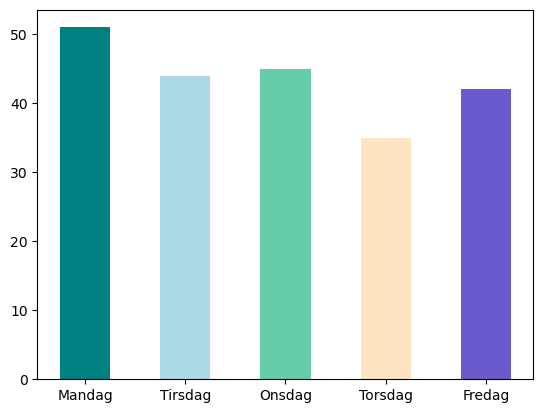

In [24]:
#lager variabler som teller oppover for hver hendvendelse som ble registrert på de ulike dagene.
mandag = 0
tirsdag = 0
onsdag = 0
torsdag = 0
fredag = 0

#går gjennom dataen over hvilke dager hendvendelsene kom på og plusser på '1' på riktig dag. 
for i in u_dag:
    if i == "Mandag":
        mandag += 1
    elif i == "Tirsdag":
        tirsdag += 1
        
    elif i == "Onsdag":
        onsdag += 1

    elif i == "Torsdag":
        torsdag += 1

    elif i == "Fredag":
        fredag += 1

#lager variabler som bruker i stolpediagram
x_akse = ("Mandag", "Tirsdag", "Onsdag", "Torsdag", "Fredag") #tilegner x-aksen dagene det kom inn hendvendelser
y_akse = [mandag, tirsdag, onsdag, torsdag, fredag] #tilegner y-aksen antallet hendvendelser som ble gjort per dag, registrert i for-løkken over.
farge = ["teal", "lightblue", "mediumaquamarine", "bisque", "slateblue"] #tilegner de ulike søylene forskjellig farge

#lager et stolpediagram med de forhåndsbestemte verdiene og søyler med en bredde på 0.5.
plt.bar(x_akse, y_akse, width = 0.5, color = farge)
plt.show() #viser stoplediagram


### Del C

Identifiserer korteste og lengste samtale til MORSE

In [25]:
#Oppretter en to liste
samtale_logg = []

#Bruker for-løkke til å iterere over 'varighet'-arrayen
for lengde in varighet:
    kort = lengde.split(":") #splitter hvert element på ':'
    time_varighet = float(kort[0])*60*60 #omgjør fra timer til sekunder
    minutt_varighet = float(kort[1])*60 #omgjør fra minutter til sekunder
    sekund_varighet = float(kort[2]) 
    varighet_per_samtale = time_varighet + minutt_varighet + sekund_varighet #legger sammen til en "tids"-variabel
    samtale_logg.append(varighet_per_samtale) #legger til hver variabel i den tomme ordboken

#finner største og laveste tall i listen ved bruk av max() of min() funksjonene
samtale_max = max(samtale_logg)
samtale_min = min(samtale_logg)
#Bruker ':.2f' for å få med kun 2 desimaler
print(f"Den lengste samtalen i uke 24 varte i {samtale_max:.2f} sekunder, mens den korteste samtale varte i {samtale_min:.2f} sekunder.")

Den lengste samtalen i uke 24 varte i 688.00 sekunder, mens den korteste samtale varte i 59.00 sekunder.


### Del D
Regner ut gjennomsnittelig samtaletid.

In [26]:
#lager en variabel
tot_samtaletid = 0

#lager en for-løkke som går gjennom alle elementene i 'varighet'
for samtale in varighet:
    a = samtale.split(":") #splitter elementene på ':' og legger det i en ny variabel 'a'
    time = float(a[0])*60*60 #omgjør element på indeks 0 fra timer til sekunder, legger inn i variabel 'time'
    minutt = float(a[1])*60 #omgjør element på indeks 1 fra minutter til sekunder til sekunder, legger inn i variabel 'minutt'
    sekund = float(a[2]) #legger inn i variabel 'sekund'
    tid_per_samtale = time + minutt + sekund #legger sammen variablene til en variabel, 'tid_per_samtale'
    tot_samtaletid += tid_per_samtale #legger 'tid_per_samtale' inn i variabelen 'tot_samtaletid'

gjennomsnitlig_samtale = (tot_samtaletid/(len(varighet))) #deler 'tot_samtaletid' på lengden av 'varighet'-array for å få gjennomsnittslengde
print(f"Den gjennomsnittelige samtalen varer i {gjennomsnitlig_samtale:.2f} sekunder.")


Den gjennomsnittelige samtalen varer i 400.01 sekunder.


### Del E
Finner antall hendvendelser basert på arbeidstid.

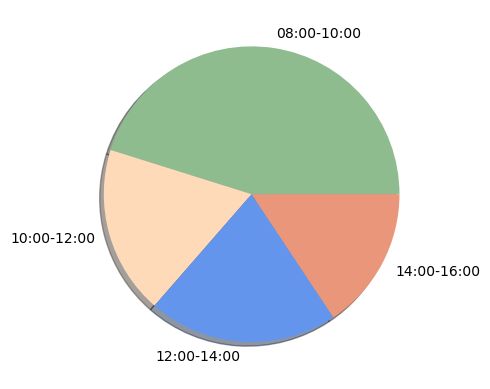

In [27]:
#lager variabler som tilsvarer vakt-inndeling
morgen = 0 # 08:00 - 10:00
formiddag = 0 # 10:00 - 12:00
ettermiddag = 0 # 12:00 - 14:00
kveld = 0 # 14:00 - 16:00
annet = 0

#lager en for-løkke som sorterer de ulike elementene ifra 'kl_slett'-arrayen inn i de ulike variablene sett ovenfor
for i in kl_slett:
    a = i.replace(":","") #erstatter ':' med '', slik at elementene blir sammenhengende "tall"
    a = int(a) #gjør om elementene fra string til int slik at programmet kan prosessere dataen stigende som sett i if-statementen nedenfor
    if a >= 80000 and a <= 95959:
        morgen += 1
    elif a >= 100000 and a <= 115959:
        formiddag += 1
    elif a >= 120000 and a <= 135959:
        ettermiddag += 1
    else:
        kveld += 1
    
#lager variabler som skal brukes i sektordiagrammet
storrelse = [morgen, formiddag, ettermiddag, kveld] #størrelsen på hver sektor er variablene som ble lagd ovenfor 
tid = ("08:00-10:00", "10:00-12:00", "12:00-14:00", "14:00-16:00") #navnene på de ulike sektorene
farge = ["darkseagreen", "peachpuff", "cornflowerblue", "darksalmon"] #fargen på de ulike sektorene

plt.pie(storrelse, labels = tid, colors = farge, shadow = True) #lager sektordiagrammet
plt.show() #plotter sektordiagrammet
    

### Del F
Regner ut NPS-scoren til MORSE

In [28]:
#lager 3 tomme lister 
positive_kunder = []
negative_kunder = []
noytrale_kunder = []

#en for-løkke som plasserer tilbakemeldingene fra kundene gitt i 'score'-arrayen i de ulike listene
for tall in score: 
    if tall <= 6:
        tall = float(tall) #gjør om elementet til et flyttall 
        negative_kunder.append(tall) #legger til i sin respektive liste
    elif tall >= 7 and tall <= 8:
        tall = float(tall)
        noytrale_kunder.append(tall)
    elif tall >= 9 and tall <=10:
        tall = float(tall)
        positive_kunder.append(tall)

total_antall = (len(positive_kunder))+(len(negative_kunder))+(len(noytrale_kunder)) #regner ut totalt antall kunder som ga tilbakemelding
nps = (len(positive_kunder)/total_antall*100) - (len(negative_kunder)/total_antall*100) #regner ut nps-scoren i prosent 
print(f"NPS-scoren for MORSE er {nps:.2f} %.")
 

NPS-scoren for MORSE er 41.86 %.
